# データサイエンス特論 第9回 演習課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302 森下剛

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE, SMOTENC


## 欠損値の補完

#### 演習問題1の回答

In [106]:
hcv_df = pd.read_csv('data/hcvdat0.csv', index_col=0)

obj_cols = hcv_df.select_dtypes(include='object').columns.tolist()
print(obj_cols)

for col in obj_cols:
    print(f'--- {col} ---')
    print(Counter(hcv_df[col]))


['Category', 'Sex']
--- Category ---
Counter({'0=Blood Donor': 533, '3=Cirrhosis': 30, '1=Hepatitis': 24, '2=Fibrosis': 21, '0s=suspect Blood Donor': 7})
--- Sex ---
Counter({'m': 377, 'f': 238})


/var/folders/q8/165rv4p93xsfzwm9wl_p779c0000gn/T/ipykernel_40233/1515124830.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = hcv_df.select_dtypes(include='object').columns.tolist()


#### 演習問題2の回答

In [107]:
hcv_bin_df = hcv_df.copy()

hcv_bin_df['Category'] = hcv_bin_df['Category'].map({'0=Blood Donor': 0, '0s=suspect Blood Donor': 0}).fillna(1).astype(int)
hcv_bin_df['Sex'] = hcv_bin_df['Sex'].map({'m': 0, 'f': 1})

print(Counter(hcv_bin_df['Category']))
print(Counter(hcv_bin_df['Sex']))

Counter({0: 540, 1: 75})
Counter({0: 377, 1: 238})


#### 演習問題3の回答

補完後の欠損数:  0


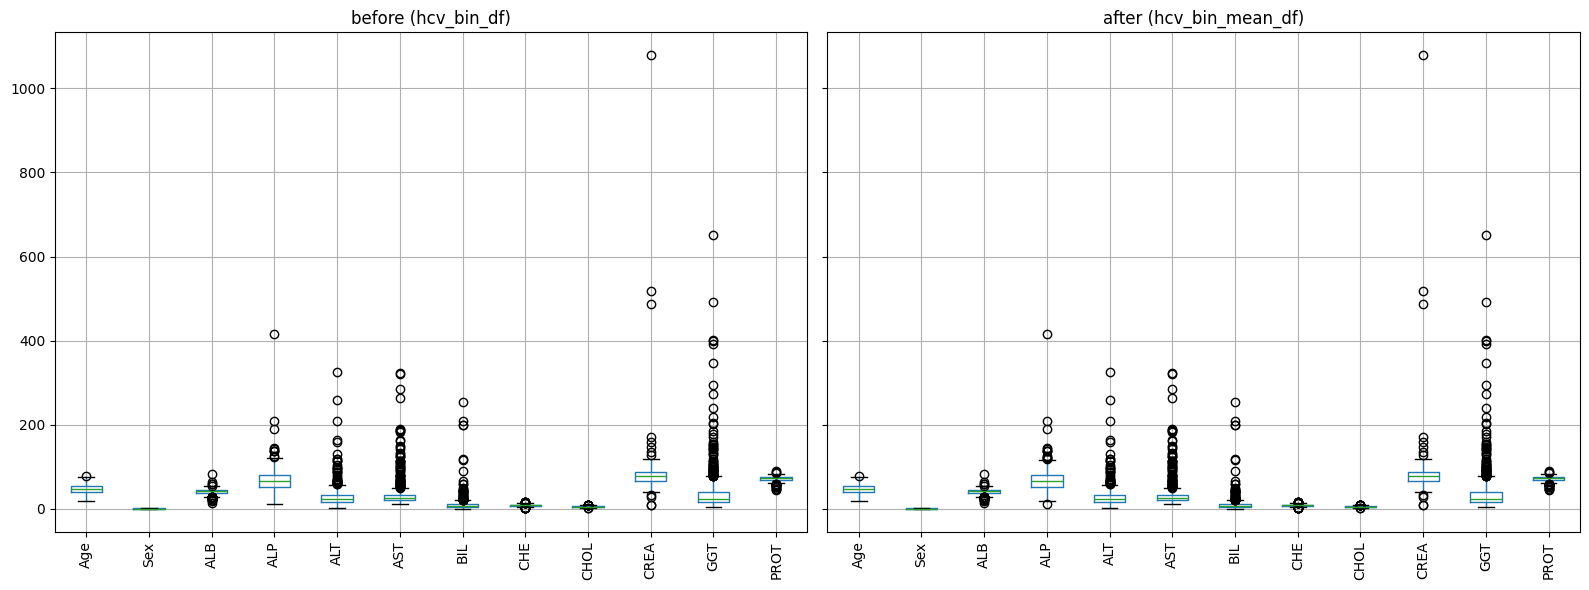

In [108]:
hcv_bin_mean_df = hcv_bin_df.fillna(hcv_bin_df.mean())

print('補完後の欠損数: ', hcv_bin_mean_df.isnull().sum().sum())

cols = hcv_bin_df.drop(columns='Category').columns

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
hcv_bin_df[cols].boxplot(ax=axes[0], rot=90)
axes[0].set_title('before (hcv_bin_df)')
hcv_bin_mean_df[cols].boxplot(ax=axes[1], rot=90)
axes[1].set_title('after (hcv_bin_mean_df)')
plt.tight_layout()
plt.show()

#### 演習問題4の回答

補完後の欠損数:  0


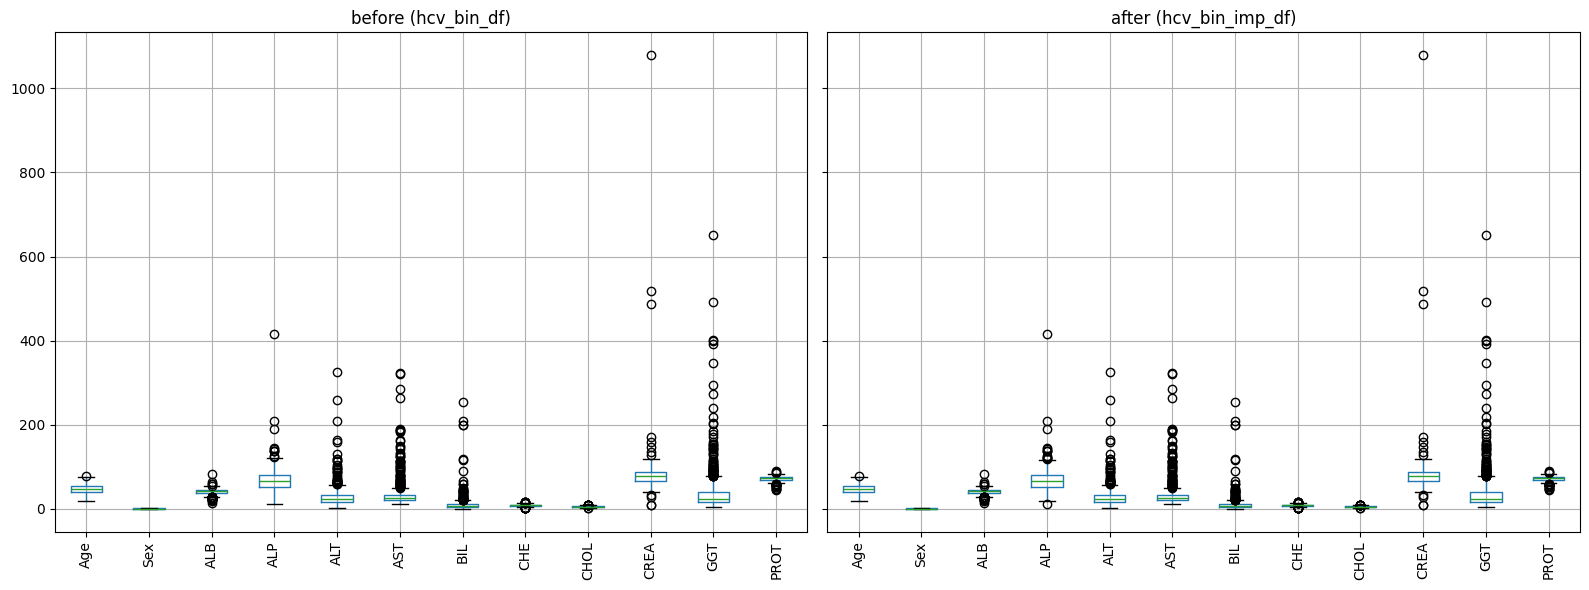

In [109]:
imputer = SimpleImputer(strategy='mean')
hcv_bin_imp_df = pd.DataFrame(
    imputer.fit_transform(hcv_bin_df),
    columns=hcv_bin_df.columns,
    index=hcv_bin_df.index,
)

print('補完後の欠損数: ', hcv_bin_imp_df.isnull().sum().sum())

cols = hcv_bin_df.drop(columns='Category').columns

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
hcv_bin_df[cols].boxplot(ax=axes[0], rot=90)
axes[0].set_title('before (hcv_bin_df)')
hcv_bin_imp_df[cols].boxplot(ax=axes[1], rot=90)
axes[1].set_title('after (hcv_bin_imp_df)')
plt.tight_layout()
plt.show()

#### 演習問題5の回答

補完後の欠損数: 0


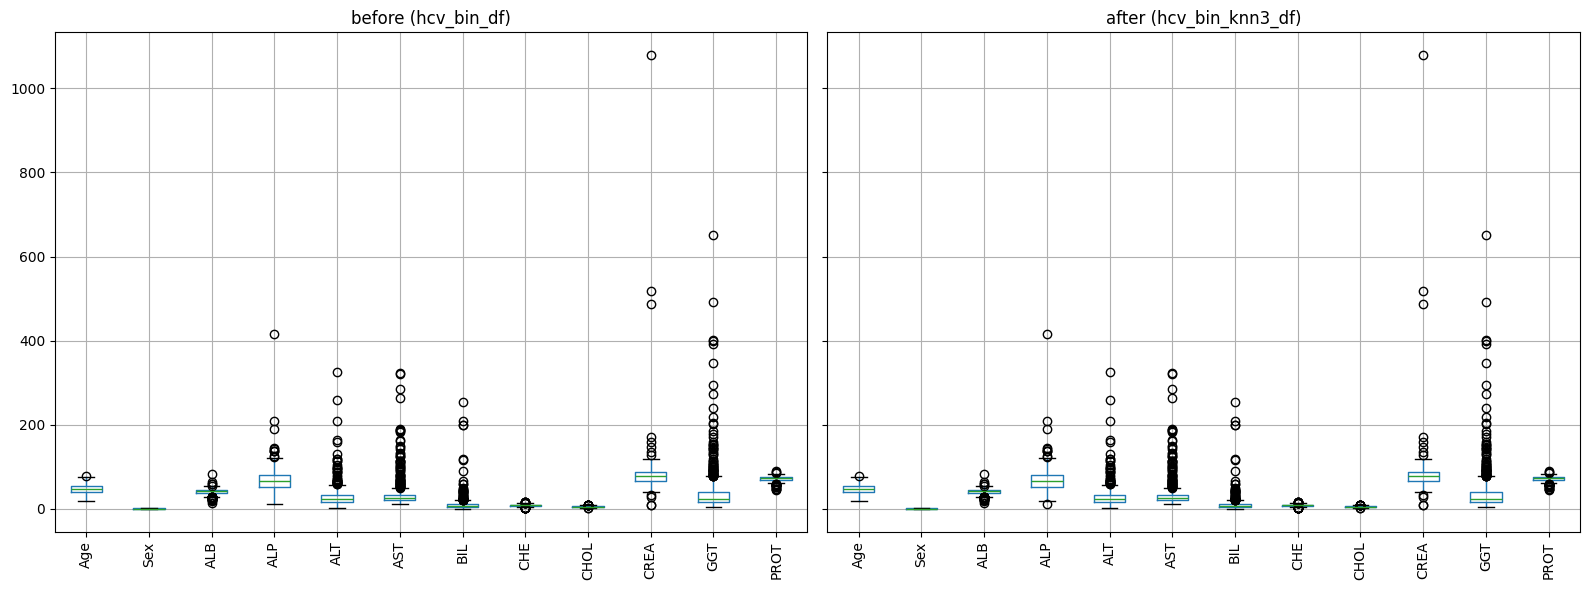

In [110]:
knn_imputer = KNNImputer(n_neighbors=3)
hcv_bin_knn3_df = pd.DataFrame(
    knn_imputer.fit_transform(hcv_bin_df),
    columns=hcv_bin_df.columns,
    index=hcv_bin_df.index,
)

print('補完後の欠損数:', hcv_bin_knn3_df.isnull().sum().sum())

cols = hcv_bin_df.drop(columns='Category').columns

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
hcv_bin_df[cols].boxplot(ax=axes[0], rot=90)
axes[0].set_title('before (hcv_bin_df)')
hcv_bin_knn3_df[cols].boxplot(ax=axes[1], rot=90)
axes[1].set_title('after (hcv_bin_knn3_df)')
plt.tight_layout()
plt.show()

## サンプリング

#### 演習問題6の回答

original: 615 after_extraction: 308


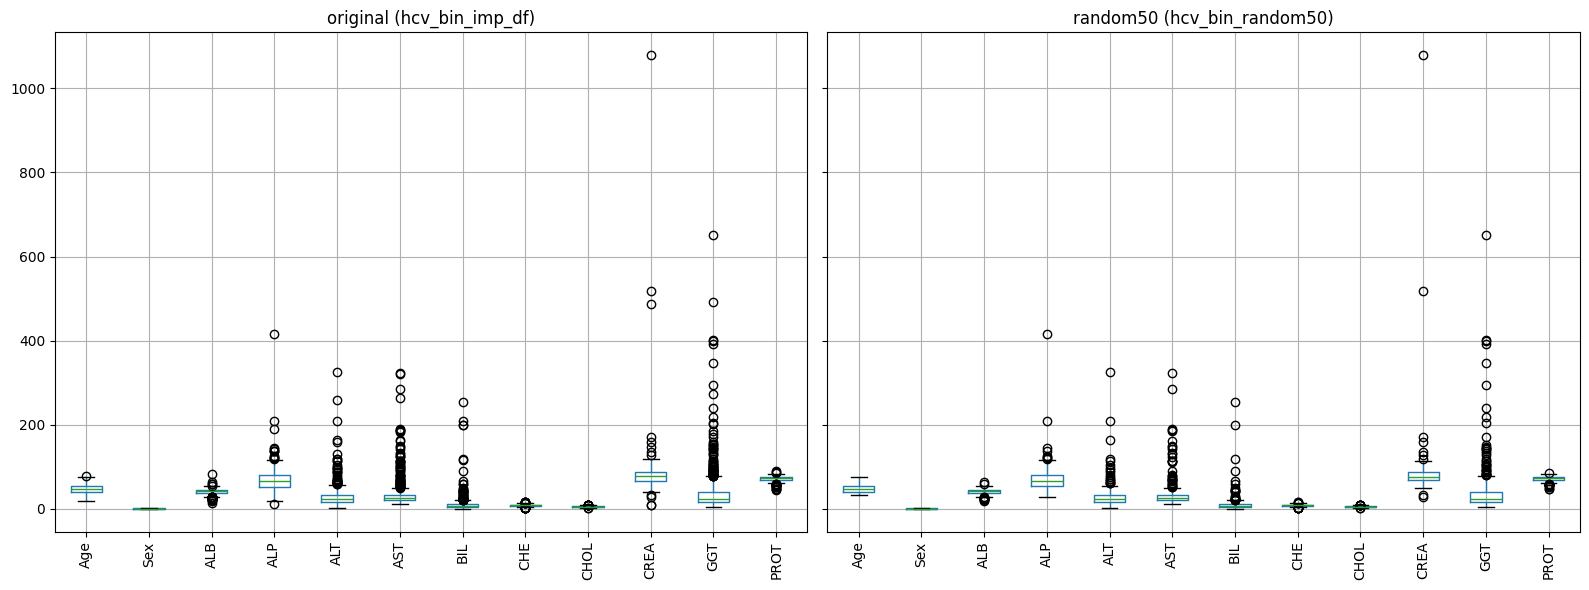

,original,random50
Category,,
0.0,0.878049,0.87987
1.0,0.121951,0.12013


In [111]:
hcv_bin_random50 = hcv_bin_imp_df.sample(frac=0.5, replace=False, random_state=0)
print('original:', len(hcv_bin_imp_df), 'after_extraction:', len(hcv_bin_random50))

cols = hcv_bin_imp_df.drop(columns='Category').columns

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
hcv_bin_imp_df[cols].boxplot(ax=axes[0], rot=90)
axes[0].set_title('original (hcv_bin_imp_df)')
hcv_bin_random50[cols].boxplot(ax=axes[1], rot=90)
axes[1].set_title('random50 (hcv_bin_random50)')
plt.tight_layout()
plt.show()

cat_compare = pd.DataFrame({
    'original': hcv_bin_imp_df['Category'].value_counts(normalize=True).sort_index(),
    'random50': hcv_bin_random50['Category'].value_counts(normalize=True).sort_index(),
})
cat_compare

#### 演習問題7の回答

original: 615 after_extraction: 308


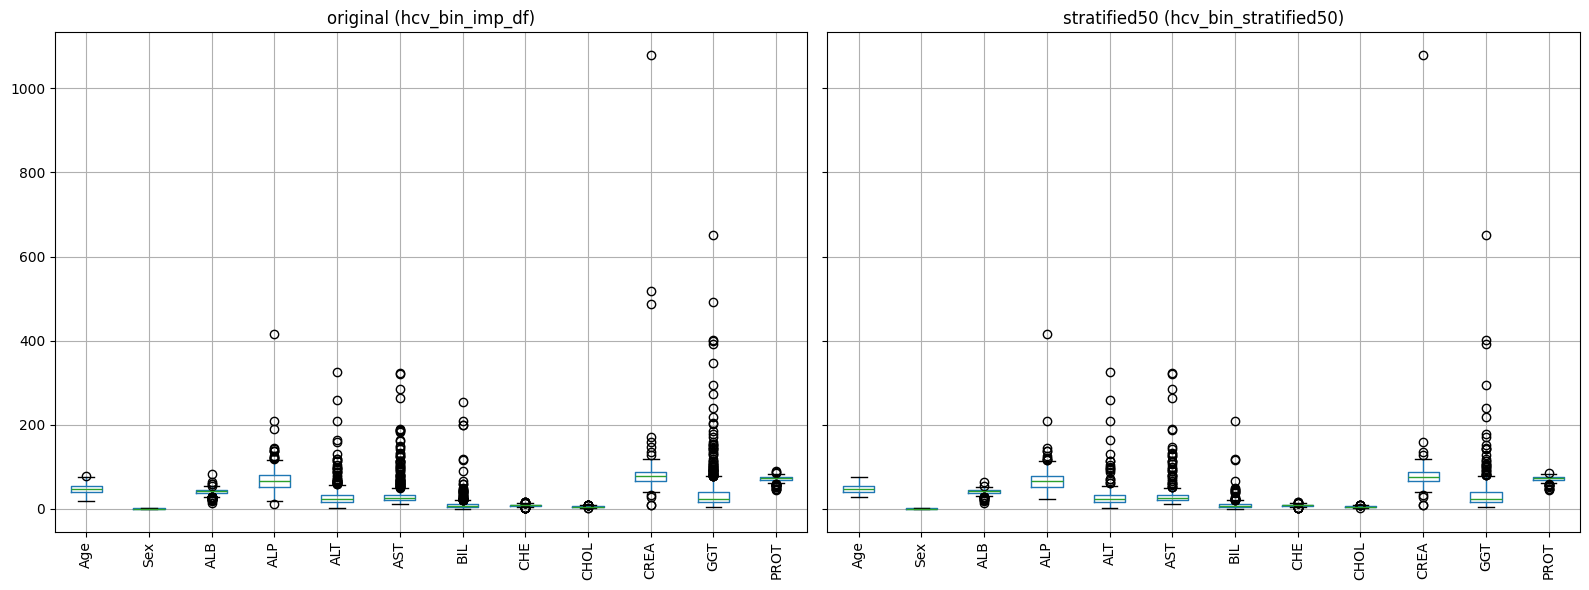

,original,stratified50
Category,,
0.0,0.878049,0.876623
1.0,0.121951,0.123377


In [112]:
hcv_bin_stratified50 = hcv_bin_imp_df.groupby('Category', group_keys=False).sample(
    frac=0.5, replace=False, random_state=0
)
print('original:', len(hcv_bin_imp_df), 'after_extraction:', len(hcv_bin_stratified50))

cols = hcv_bin_imp_df.drop(columns='Category').columns

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
hcv_bin_imp_df[cols].boxplot(ax=axes[0], rot=90)
axes[0].set_title('original (hcv_bin_imp_df)')
hcv_bin_stratified50[cols].boxplot(ax=axes[1], rot=90)
axes[1].set_title('stratified50 (hcv_bin_stratified50)')
plt.tight_layout()
plt.show()

cat_compare = pd.DataFrame({
    'original': hcv_bin_imp_df['Category'].value_counts(normalize=True).sort_index(),
    'stratified50': hcv_bin_stratified50['Category'].value_counts(normalize=True).sort_index(),
})
cat_compare

#### 演習問題8の回答

counts: {0.0: 540, 1.0: 75}
original: 75 after_sampling: 540


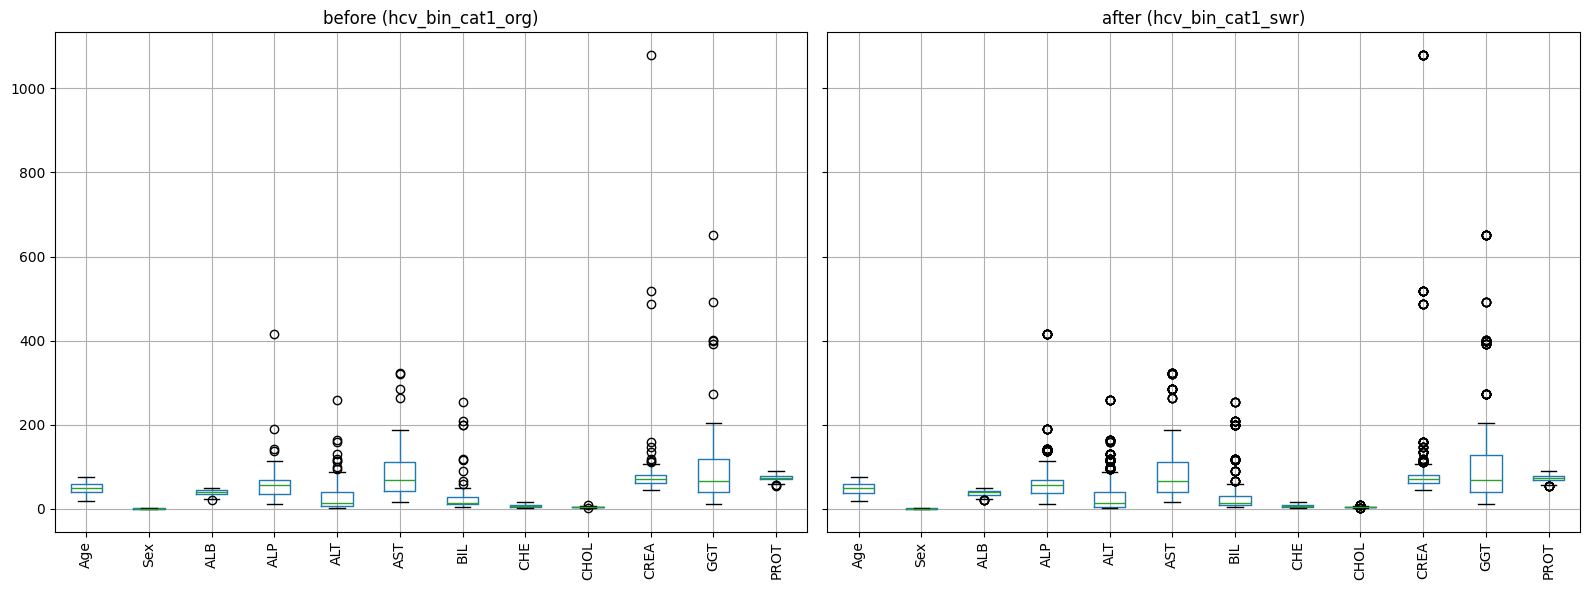

In [113]:
counts = hcv_bin_imp_df['Category'].value_counts()
print('counts:', counts.to_dict())
majority_label = counts.idxmax()
minority_label = counts.idxmin()
n_majority = counts.max()

hcv_bin_cat1_org = hcv_bin_imp_df[hcv_bin_imp_df['Category'] == minority_label]

hcv_bin_cat1_swr = hcv_bin_cat1_org.sample(n=n_majority, replace=True, random_state=0)

print('original:', len(hcv_bin_cat1_org), 'after_sampling:', len(hcv_bin_cat1_swr))

cols = hcv_bin_imp_df.drop(columns='Category').columns

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
hcv_bin_cat1_org[cols].boxplot(ax=axes[0], rot=90)
axes[0].set_title('before (hcv_bin_cat1_org)')
hcv_bin_cat1_swr[cols].boxplot(ax=axes[1], rot=90)
axes[1].set_title('after (hcv_bin_cat1_swr)')
plt.tight_layout()
plt.show()

箱が変化していないので良い感じに見えるが、外れ値が濃くなっていることから、元のサンプルに強く影響されている。

#### 演習問題9の回答

original: Counter({0.0: 540, 1.0: 75})
after_sampling: Counter({0.0: 540, 1.0: 540})


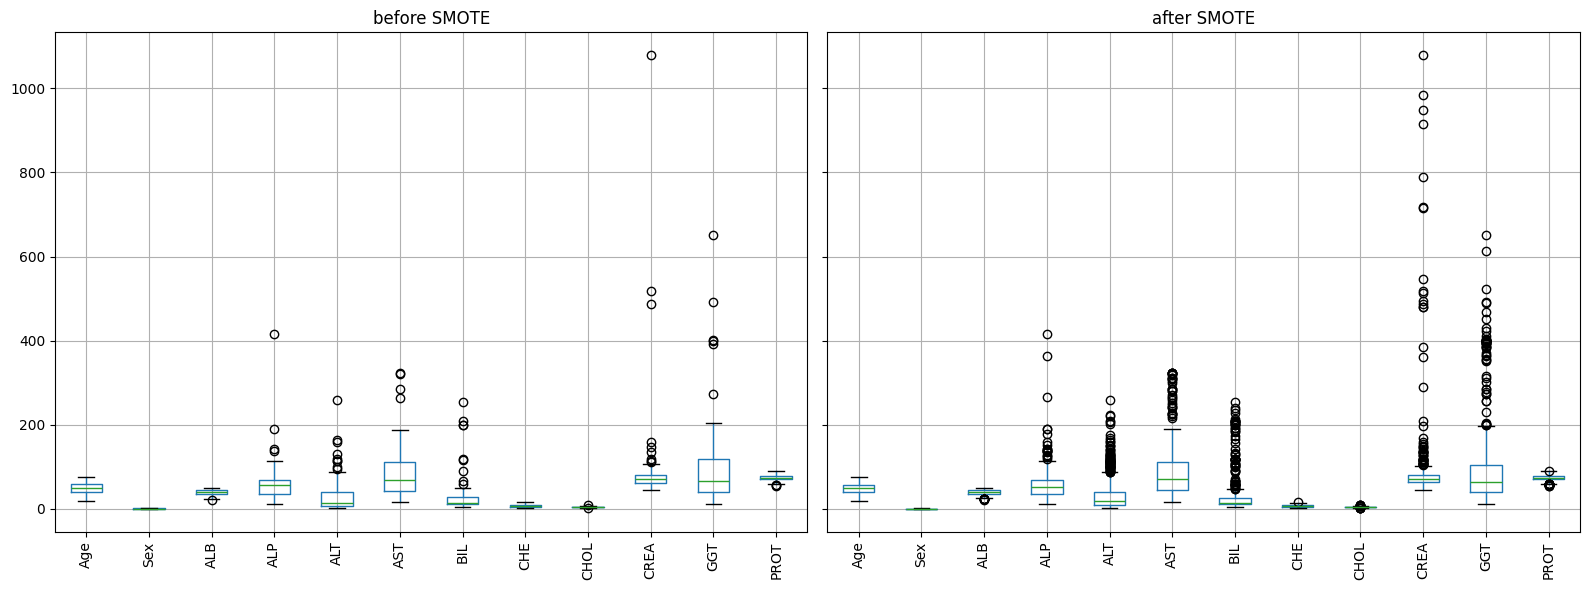

In [114]:
X = hcv_bin_imp_df.drop(columns='Category')
y = hcv_bin_imp_df['Category']

smote = SMOTE(random_state=0)
X_res, y_res = smote.fit_resample(X, y)

hcv_bin_smote = X_res.copy()
hcv_bin_smote['Category'] = y_res

print('original:', Counter(y))
print('after_sampling:', Counter(hcv_bin_smote['Category']))

minority_label = y.value_counts().idxmin()
before = hcv_bin_imp_df[hcv_bin_imp_df['Category'] == minority_label]
after = hcv_bin_smote[hcv_bin_smote['Category'] == minority_label]

cols = X.columns

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
before[cols].boxplot(ax=axes[0], rot=90)
axes[0].set_title('before SMOTE')
after[cols].boxplot(ax=axes[1], rot=90)
axes[1].set_title('after SMOTE')
plt.tight_layout()
plt.show()

箱がずれないことはもちろん、外れ値がいい感じに分布しているので、バイアスなくサンプリング出来ていると感じる。

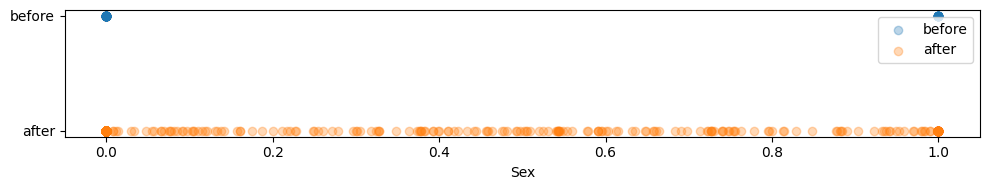

In [115]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.scatter(before['Sex'], [1] * len(before), alpha=0.3, label='before')
ax.scatter(after['Sex'], [0] * len(after), alpha=0.3, label='after')
ax.set_yticks([0, 1])
ax.set_yticklabels(['after', 'before'])
ax.set_xlabel('Sex')
ax.legend()
plt.tight_layout()
plt.show()


カテゴリカル変数は正常にサンプリング出来ていないことがわかる。

#### 演習問題10の回答

**発生する問題**
- SMOTE は全ての属性を連続値とみなしてサンプルを生成する。
- つまり0または1のみをとるSexのような属性に対しても同じようにサンプリングするため2値以外の値が発生することが問題である。

**解決方法**
- カテゴリカル属性を扱える SMOTENC を用いる。
- categorical_features に Sex を指定することで2値を保ったままサンプルを生成できる。

original: Counter({0.0: 540, 1.0: 75})
after_sampling: Counter({0.0: 540, 1.0: 540})


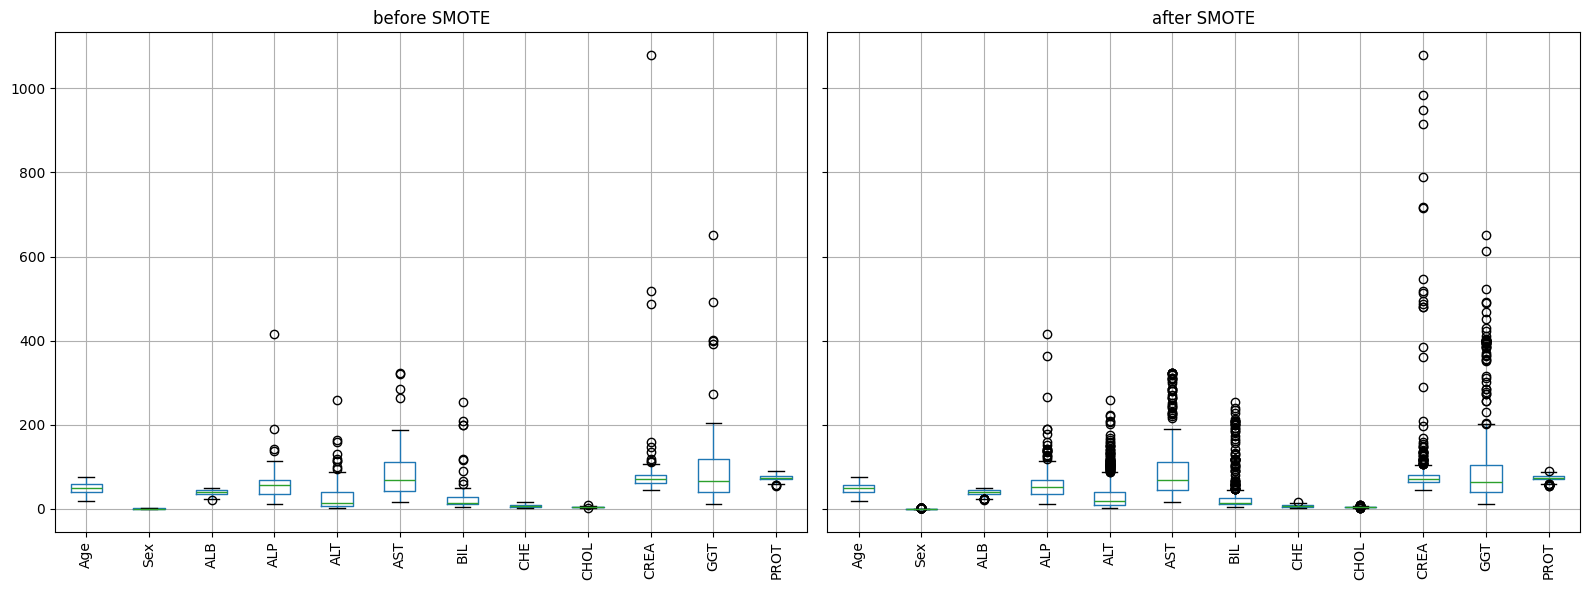

In [116]:
X = hcv_bin_imp_df.drop(columns='Category')
y = hcv_bin_imp_df['Category']

smote = SMOTENC(random_state=0, categorical_features=['Sex'])
X_res, y_res = smote.fit_resample(X, y)

hcv_bin_smote = X_res.copy()
hcv_bin_smote['Category'] = y_res

print('original:', Counter(y))
print('after_sampling:', Counter(hcv_bin_smote['Category']))

minority_label = y.value_counts().idxmin()
before = hcv_bin_imp_df[hcv_bin_imp_df['Category'] == minority_label]
after = hcv_bin_smote[hcv_bin_smote['Category'] == minority_label]

cols = X.columns

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
before[cols].boxplot(ax=axes[0], rot=90)
axes[0].set_title('before SMOTE')
after[cols].boxplot(ax=axes[1], rot=90)
axes[1].set_title('after SMOTE')
plt.tight_layout()
plt.show()

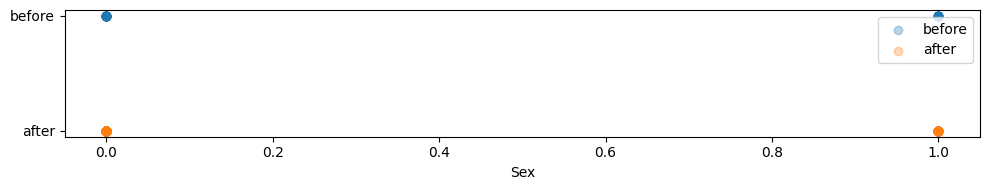

In [117]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.scatter(before['Sex'], [1] * len(before), alpha=0.3, label='before')
ax.scatter(after['Sex'], [0] * len(after), alpha=0.3, label='after')
ax.set_yticks([0, 1])
ax.set_yticklabels(['after', 'before'])
ax.set_xlabel('Sex')
ax.legend()
plt.tight_layout()
plt.show()

このように正しくサンプリングされたことが確認できた。